# Ensemble Learning: Gradient Boosting — Manual Walkthrough on Tabular Data

---

## Introduction

This notebook walks through the **Gradient Boosting algorithm step by step** on a small tabular dataset, making every computation traceable by hand. Rather than using scikit-learn's `GradientBoostingRegressor` as a black box, each round is implemented explicitly so the update rule is fully visible.

### The Algorithm — Two Rounds Expanded

| Step | Formula | Description |
|---|---|---|
| Initialize | $f_0(x) = \bar{y}$ | Start with the mean of the target |
| Residual 1 | $r_i^{(1)} = y_i - f_0(x_i)$ | Error of the initial prediction |
| Tree 1 | $h_1(x) \approx r^{(1)}$ | Fit a tree to residuals |
| Update 1 | $f_1(x) = f_0(x) + \eta \cdot h_1(x)$ | Add shrunk tree to ensemble |
| Residual 2 | $r_i^{(2)} = y_i - f_1(x_i)$ | Error of the updated prediction |
| Tree 2 | $h_2(x) \approx r^{(2)}$ | Fit a second tree to new residuals |
| Update 2 | $f_2(x) = f_1(x) + \eta \cdot h_2(x)$ | Add second tree to ensemble |

The **learning rate** $\eta$ (here `0.1`) shrinks each tree's contribution, preventing the ensemble from overfitting to individual rounds. A smaller $\eta$ requires more trees but generally produces better generalization.

### Workflow

1. Load the dataset and inspect the target
2. Initialize predictions with the target mean
3. Compute Round 1 residuals and fit Tree 1
4. Update predictions and compute Round 2 residuals
5. Fit Tree 2 and finalize Round 2 predictions
6. Track residual decay across rounds

---

## 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import r2_score, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

LEARNING_RATE = 0.1

---

## 2. Loading and Exploring the Dataset

In [3]:
df = pd.read_csv('GB_data.csv')

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print('\nMissing values:', df.isnull().sum().sum())
df

Shape: (3, 4)
Columns: ['R&D_spend', 'Administration', 'Marckting spend', 'profit']

Missing values: 0


,R&D_spend,Administration,Marckting spend,profit
0,165,137,472,192
1,101,92,250,144
2,29,127,201,91


In [4]:
df.describe().round(4)

,R&D_spend,Administration,Marckting spend,profit
count,3.0000,3.0000,3.0000,3.0000
mean,98.3333,118.6667,307.6667,142.3333
std,68.0392,23.6291,144.4103,50.5206
min,29.0000,92.0000,201.0000,91.0000
25%,65.0000,109.5000,225.5000,117.5000
50%,101.0000,127.0000,250.0000,144.0000
75%,133.0000,132.0000,361.0000,168.0000
max,165.0000,137.0000,472.0000,192.0000


---

## 3. Step 1 — Initialize with the Target Mean

The ensemble starts with the simplest possible model: predict the **mean** of the target for every sample. This is the constant that minimizes the mean squared error over the training set.

$$f_0(x) = \bar{y} = \frac{1}{N}\sum_{i=1}^N y_i$$

In [5]:
y_mean = df['profit'].mean()
df['f0(x)'] = y_mean

print(f'Target mean  : {y_mean:.4f}')
print(f'Initial MSE  : {mean_squared_error(df["profit"], df["f0(x)"]):.4f}')
print(f'Initial R²   : {r2_score(df["profit"], df["f0(x)"]):.4f}')
df[['profit', 'f0(x)']]

Target mean  : 142.3333
Initial MSE  : 1701.5556
Initial R²   : 0.0000


,profit,f0(x)
0,192,142.333333
1,144,142.333333
2,91,142.333333


---

## 4. Round 1 — Residuals and First Tree

### Step 2: Compute Round 1 Residuals

The residuals $r_i^{(1)} = y_i - f_0(x_i)$ capture the prediction error of the current ensemble. Each subsequent tree is trained to predict these residuals — effectively learning what the ensemble still gets wrong.

In [6]:
df['res1'] = df['profit'] - df['f0(x)']

print('Round 1 Residuals:')
print(f'  Mean : {df["res1"].mean():.4f}  (should be ~0 since f0 = mean)')
print(f'  Std  : {df["res1"].std():.4f}')
df[['profit', 'f0(x)', 'res1']]

Round 1 Residuals:
  Mean : -0.0000  (should be ~0 since f0 = mean)
  Std  : 50.5206


,profit,f0(x),res1
0,192,142.333333,49.666667
1,144,142.333333,1.666667
2,91,142.333333,-51.333333


### Step 3: Fit Tree 1 to Residuals

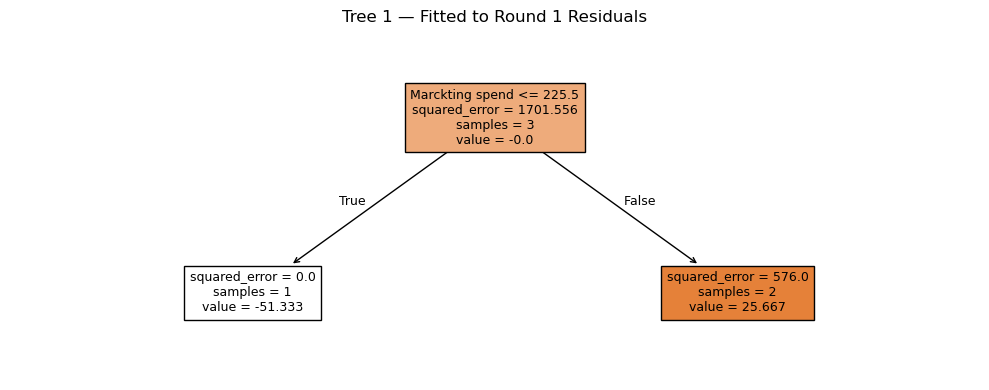

In [7]:
feature_cols = df.columns[:3].tolist()
X_features   = df[feature_cols].values

dt1 = DecisionTreeRegressor(max_depth=1, random_state=42)
dt1.fit(X_features, df['res1'].values)

plt.figure(figsize=(10, 4))
plot_tree(dt1, feature_names=feature_cols, filled=True, fontsize=9)
plt.title('Tree 1 — Fitted to Round 1 Residuals')
plt.tight_layout()
plt.show()

### Step 4: Update Prediction — Round 1

The ensemble prediction after Round 1 adds the first tree's output, scaled by the learning rate:

$$f_1(x) = f_0(x) + \eta \cdot h_1(x)$$

With $\eta = 0.1$, each tree contributes only 10% of its prediction, preventing the ensemble from jumping too aggressively toward any single tree's output.

In [8]:
df['f1(x)'] = df['f0(x)'] + LEARNING_RATE * dt1.predict(X_features)

r2_r1  = r2_score(df['profit'], df['f1(x)'])
mse_r1 = mean_squared_error(df['profit'], df['f1(x)'])

print(f'Round 1  —  R²: {r2_r1:.4f}   MSE: {mse_r1:.4f}')
df[['profit', 'f0(x)', 'res1', 'f1(x)']]

Round 1  —  R²: 0.1471   MSE: 1451.2200


,profit,f0(x),res1,f1(x)
0,192,142.333333,49.666667,144.9
1,144,142.333333,1.666667,144.9
2,91,142.333333,-51.333333,137.2


---

## 5. Round 2 — Residuals and Second Tree

### Step 5: Compute Round 2 Residuals

Round 2 residuals are computed from the updated prediction $f_1(x)$:

$$r_i^{(2)} = y_i - f_1(x_i)$$

These are smaller in magnitude than Round 1 residuals — the ensemble has already captured some structure. Tree 2 focuses on what Round 1 still gets wrong.

In [10]:
df['res2'] = df['profit'] - df['f1(x)']

print('Residual Comparison:')
print(f'  Round 1 residual std : {df["res1"].std():.4f}')
print(f'  Round 2 residual std : {df["res2"].std():.4f}')
print(f'  Reduction            : {(1 - df["res2"].std()/df["res1"].std())*100:.2f}%')
df[['profit', 'f1(x)', 'res2']]

Residual Comparison:
  Round 1 residual std : 50.5206
  Round 2 residual std : 46.6565
  Reduction            : 7.65%


,profit,f1(x),res2
0,192,144.9,47.1
1,144,144.9,-0.9
2,91,137.2,-46.2


### Step 6: Fit Tree 2 to Round 2 Residuals

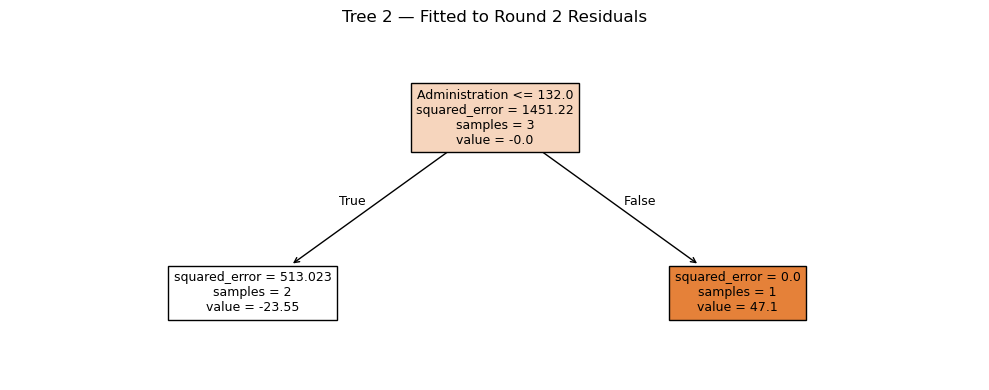

In [11]:
dt2 = DecisionTreeRegressor(max_depth=1, random_state=42)
dt2.fit(X_features, df['res2'].values)

plt.figure(figsize=(10, 4))
plot_tree(dt2, feature_names=feature_cols, filled=True, fontsize=9)
plt.title('Tree 2 — Fitted to Round 2 Residuals')
plt.tight_layout()
plt.show()

### Step 7: Update Prediction — Round 2

$$f_2(x) = f_1(x) + \eta \cdot h_2(x)$$

In [12]:
df['f2(x)'] = df['f1(x)'] + LEARNING_RATE * dt2.predict(X_features)

r2_r2  = r2_score(df['profit'], df['f2(x)'])
mse_r2 = mean_squared_error(df['profit'], df['f2(x)'])

print(f'Round 2  —  R²: {r2_r2:.4f}   MSE: {mse_r2:.4f}')
df[['profit', 'f0(x)', 'f1(x)', 'f2(x)']]

Round 2  —  R²: 0.2710   MSE: 1240.4711


,profit,f0(x),f1(x),f2(x)
0,192,142.333333,144.9,149.610
1,144,142.333333,144.9,142.545
2,91,142.333333,137.2,134.845


---

## 6. Full State Table

The complete state of the boosting process across both rounds — predictions, residuals, and tree outputs — in one view.

In [13]:
df['res3'] = df['profit'] - df['f2(x)']

display_cols = ['profit', 'f0(x)', 'res1', 'f1(x)', 'res2', 'f2(x)', 'res3']
print('Full Gradient Boosting State Table:')
df[display_cols].round(4)

Full Gradient Boosting State Table:


,profit,f0(x),res1,f1(x),res2,f2(x),res3
0,192,142.3333,49.6667,144.9,47.1,149.610,42.390
1,144,142.3333,1.6667,144.9,-0.9,142.545,1.455
2,91,142.3333,-51.3333,137.2,-46.2,134.845,-43.845


---

## 7. Residual Decay and R² Across Rounds

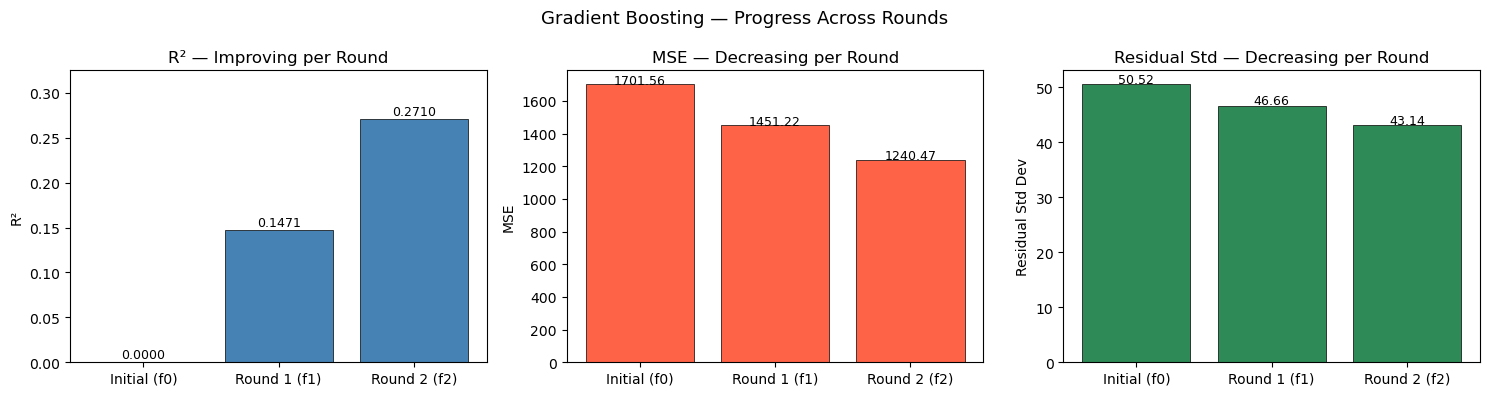

In [14]:
rounds    = ['Initial (f0)', 'Round 1 (f1)', 'Round 2 (f2)']
r2_vals   = [
    
    r2_score(df['profit'], df['f0(x)']),
    r2_r1,
    r2_r2
]
mse_vals  = [
    mean_squared_error(df['profit'], df['f0(x)']),
    mse_r1,
    mse_r2
]
res_stds  = [
    df['res1'].std(),
    df['res2'].std(),
    df['res3'].std()
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(rounds, r2_vals, color='steelblue', edgecolor='k', linewidth=0.5)
axes[0].set_ylabel('R²')
axes[0].set_title('R² — Improving per Round')
axes[0].set_ylim(0, max(r2_vals) * 1.2)
for i, v in enumerate(r2_vals):
    axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=9)

axes[1].bar(rounds, mse_vals, color='tomato', edgecolor='k', linewidth=0.5)
axes[1].set_ylabel('MSE')
axes[1].set_title('MSE — Decreasing per Round')
for i, v in enumerate(mse_vals):
    axes[1].text(i, v + 0.5, f'{v:.2f}', ha='center', fontsize=9)

axes[2].bar(rounds, res_stds, color='seagreen', edgecolor='k', linewidth=0.5)
axes[2].set_ylabel('Residual Std Dev')
axes[2].set_title('Residual Std — Decreasing per Round')
for i, v in enumerate(res_stds):
    axes[2].text(i, v + 0.2, f'{v:.2f}', ha='center', fontsize=9)

plt.suptitle('Gradient Boosting — Progress Across Rounds', fontsize=13)
plt.tight_layout()
plt.show()

---

## 8. Results Summary

In [15]:
summary = pd.DataFrame({
    'Stage':        rounds,
    'Prediction':   ['f0(x)', 'f1(x)', 'f2(x)'],
    'R²':           [round(v, 4) for v in r2_vals],
    'MSE':          [round(v, 4) for v in mse_vals],
    'Residual Std': [round(v, 4) for v in res_stds]
})

print(summary.to_string(index=False))

       Stage Prediction     R²       MSE  Residual Std
Initial (f0)      f0(x) 0.0000 1701.5556       50.5206
Round 1 (f1)      f1(x) 0.1471 1451.2200       46.6565
Round 2 (f2)      f2(x) 0.2710 1240.4711       43.1359


---

## Conclusion

This notebook walked through two complete rounds of Gradient Boosting on the tabular profit dataset, making every residual, tree fit, and prediction update fully visible in the DataFrame.

**Key findings:**

- **Round 0** — the initial mean prediction produces uniformly large residuals. R² is near zero since no feature-based structure has been learned.
- **Round 1** — Tree 1 fits the residuals and captures the primary signal in the features, producing the first meaningful improvement in R² and MSE.
- **Round 2** — Tree 2 targets the residuals left by Round 1, further reducing prediction error. The residual standard deviation decreases with each round, confirming that real signal is being captured rather than noise.
- The **learning rate of 0.1** means each tree contributes only 10% of its prediction. This conservative step size prevents the ensemble from overfitting to individual rounds and ensures smoother convergence over more rounds.
- The **full state table** makes it clear that `res2 < res1` for every sample — each round genuinely reduces the individual errors.

**Takeaways:**

- The key insight of Gradient Boosting is that residuals are the negative gradient of MSE loss — fitting a tree to them is equivalent to one step of gradient descent in function space.
- `learning_rate` and `n_estimators` are the primary controls: smaller learning rate with more estimators almost always outperforms a large learning rate with fewer trees.
- `max_depth=1` (stumps) was used here for interpretability. In practice, `max_depth=3–5` is standard for Gradient Boosting to capture interaction effects.
- `sklearn.ensemble.GradientBoostingRegressor` automates this entire process and adds row subsampling, column subsampling, and regularization. **XGBoost** and **LightGBM** implement the same algorithm with second-order gradient information and faster tree construction.